In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
!pip install numpy pillow torch torchvision

# LFW PEOPLE

Labeled Faces in the Wild (LFW) people dataset is a widely used benchmark dataset for face recognition and verification tasks. 

- Total Samples: 13,233 face images
- Classes (People): 5,749 distinct individuals
- Image Source: Collected from various websites and aligned using face detection algorithms (e.g., Viola-Jones). 
- Task Type: Face identification (classification) and face verification (matching pairs).

The input consists of face images represented as numerical data. The output is the identity (name) of the person in the face image — a multi-class classification task known as face identification.

In [3]:
import numpy as np
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

In [4]:
# Load dataset
print("Loading LFW dataset (only people with at least 70 photos)...")
lfw = fetch_lfw_people(min_faces_per_person=70, resize=0.4, color=False)

X = lfw.images          # shape: (n_samples, height=50, width=37)
y = lfw.target
target_names = lfw.target_names

print(f"Loaded {X.shape[0]} images")
print(f"Image size: {X.shape[1]}x{X.shape[2]}")
print(f"Number of people (classes): {len(target_names)}")

Loading LFW dataset (only people with at least 70 photos)...
Loaded 1288 images
Image size: 50x37
Number of people (classes): 7


In [5]:
# Preprocess for pytorch
X = X.astype('float32') / 255.0
X = X.reshape(-1, 1, X.shape[1], X.shape[2])   # (N, C=1, H, W) - PyTorch format

# Split into train/test (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Further split train → train + validation (like the Keras version)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# Convert to PyTorch tensors
X_train = torch.from_numpy(X_train)
X_val   = torch.from_numpy(X_val)
X_test  = torch.from_numpy(X_test)
y_train = torch.from_numpy(y_train).long()
y_val   = torch.from_numpy(y_val).long()
y_test  = torch.from_numpy(y_test).long()

# DataLoaders
train_dataset = TensorDataset(X_train, y_train)
val_dataset   = TensorDataset(X_val, y_val)
test_dataset  = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

num_classes = len(np.unique(y))
print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples: {len(X_test)}")

Training samples: 772
Validation samples: 194
Test samples: 322


In [6]:
# build a CNN
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.5)
        
        # After 2× pooling on 50×37 → 64 × 12 × 9
        self.fc1 = nn.Linear(64 * 12 * 9, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)          # flatten
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [7]:
# setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = SimpleCNN(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Using device: cuda


In [8]:
# model training
print("Training the CNN...")

epochs = 20
train_accs = []
val_accs = []

for epoch in range(epochs):
    model.train()
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    train_acc = 100 * correct / total
    train_accs.append(train_acc)

    # Validation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    val_acc = 100 * correct / total
    val_accs.append(val_acc)
    
    print(f"Epoch {epoch+1:2d}/{epochs} | Train Acc: {train_acc:6.2f}% | Val Acc: {val_acc:6.2f}%")

Training the CNN...
Epoch  1/20 | Train Acc:  38.21% | Val Acc:  41.24%
Epoch  2/20 | Train Acc:  40.93% | Val Acc:  41.24%
Epoch  3/20 | Train Acc:  40.93% | Val Acc:  41.24%
Epoch  4/20 | Train Acc:  41.06% | Val Acc:  41.24%
Epoch  5/20 | Train Acc:  41.06% | Val Acc:  41.24%
Epoch  6/20 | Train Acc:  40.93% | Val Acc:  41.24%
Epoch  7/20 | Train Acc:  41.06% | Val Acc:  41.24%
Epoch  8/20 | Train Acc:  41.06% | Val Acc:  41.24%
Epoch  9/20 | Train Acc:  41.06% | Val Acc:  41.24%
Epoch 10/20 | Train Acc:  41.06% | Val Acc:  41.24%
Epoch 11/20 | Train Acc:  41.06% | Val Acc:  41.24%
Epoch 12/20 | Train Acc:  41.06% | Val Acc:  41.24%
Epoch 13/20 | Train Acc:  41.06% | Val Acc:  41.24%
Epoch 14/20 | Train Acc:  41.06% | Val Acc:  41.24%
Epoch 15/20 | Train Acc:  41.06% | Val Acc:  41.24%
Epoch 16/20 | Train Acc:  41.06% | Val Acc:  41.24%
Epoch 17/20 | Train Acc:  41.06% | Val Acc:  41.24%
Epoch 18/20 | Train Acc:  41.06% | Val Acc:  41.24%
Epoch 19/20 | Train Acc:  41.06% | Val Acc: 

In [9]:
# evaluate on test set
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_acc = 100 * correct / total
print(f"Test Accuracy: {test_acc:.2f}%")

Test Accuracy: 41.30%


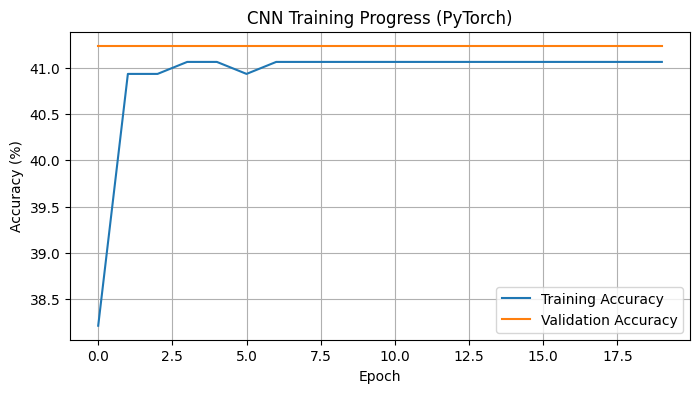

In [10]:
# plot curves
plt.figure(figsize=(8, 4))
plt.plot(train_accs, label='Training Accuracy')
plt.plot(val_accs, label='Validation Accuracy')
plt.title('CNN Training Progress (PyTorch)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.show()

In [11]:
# ====================== 8. EXAMPLE PREDICTION ======================
model.eval()
idx = 0
sample = X_test[idx:idx+1].to(device)
true_person = target_names[y_test[idx].item()]

with torch.no_grad():
    output = model(sample)
    predicted_idx = torch.argmax(output, dim=1).item()
    predicted_person = target_names[predicted_idx]

print(f"\nExample prediction:")
print(f"True person : {true_person}")
print(f"Predicted   : {predicted_person}")


Example prediction:
True person : Colin Powell
Predicted   : George W Bush
